In [1]:
from google.colab import files
uploaded = files.upload()   # seasonal_agriculture_performance_dataset.csv upload kara

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [5]:
print(df.isnull().sum())

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [6]:
# Numeric columns che missing values median ne bharuya (season-wise median jasta accurate)
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

# Duplicate rows check & remove
print("Duplicates:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# Farm_ID unique check
print("Unique Farm IDs:", df['Farm_ID'].nunique(), "/", len(df))

print("Missing values after cleaning:\n", df.isnull().sum().sum())

Duplicates: 0
Unique Farm IDs: 4000 / 4000
Missing values after cleaning:
 0


In [7]:
season_summary = df.groupby('Season')[['Yield_Tonnes_Ha','Profit_INR','Revenue_INR',
                                         'Total_Cost_INR','Water_Used_m3',
                                         'Fertilizer_kg_ha','Pesticide_Litre_ha',
                                         'Disease_Pest_Risk_pct']].mean().round(2)
season_summary

,Yield_Tonnes_Ha,Profit_INR,Revenue_INR,Total_Cost_INR,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,178914.65,710719.06,531804.41,6102.20,187.08,5.08,54.47
Rabi,5.04,87689.47,601526.05,513836.58,5846.99,185.41,5.02,40.48
Zaid,4.64,-24804.82,519171.90,543976.73,6419.89,184.64,5.17,38.22


/tmp/ipykernel_4212/160047772.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2')


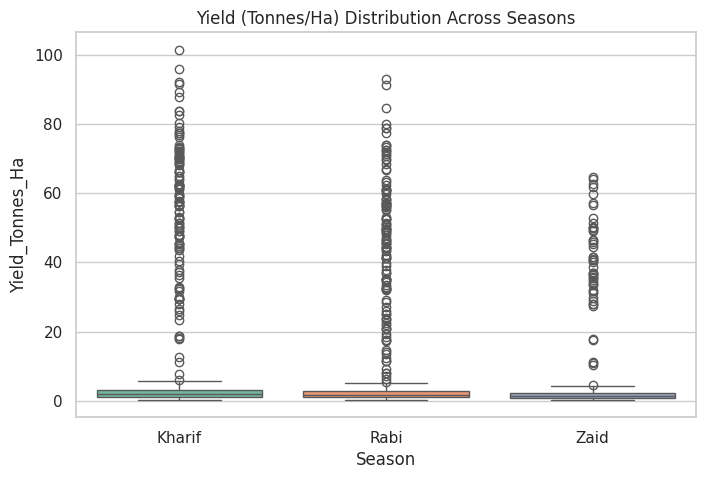

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2')
plt.title("Yield (Tonnes/Ha) Distribution Across Seasons")
plt.savefig("01_yield_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4212/3536715721.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Profit_INR', estimator=np.mean, palette='Set3')


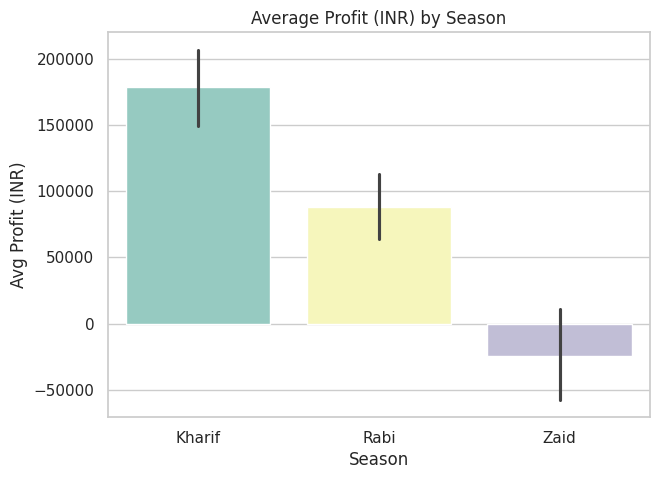

In [12]:
plt.figure(figsize=(7,5))
sns.barplot(data=df, x='Season', y='Profit_INR', estimator=np.mean, palette='Set3')
plt.title("Average Profit (INR) by Season")
plt.ylabel("Avg Profit (INR)")
plt.savefig("02_avg_profit_by_season.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4212/2204998665.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Season', y='Rainfall_mm', ax=ax[0], palette='Blues')
/tmp/ipykernel_4212/2204998665.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Season', y='Avg_Temperature_C', ax=ax[1], palette='Oranges')


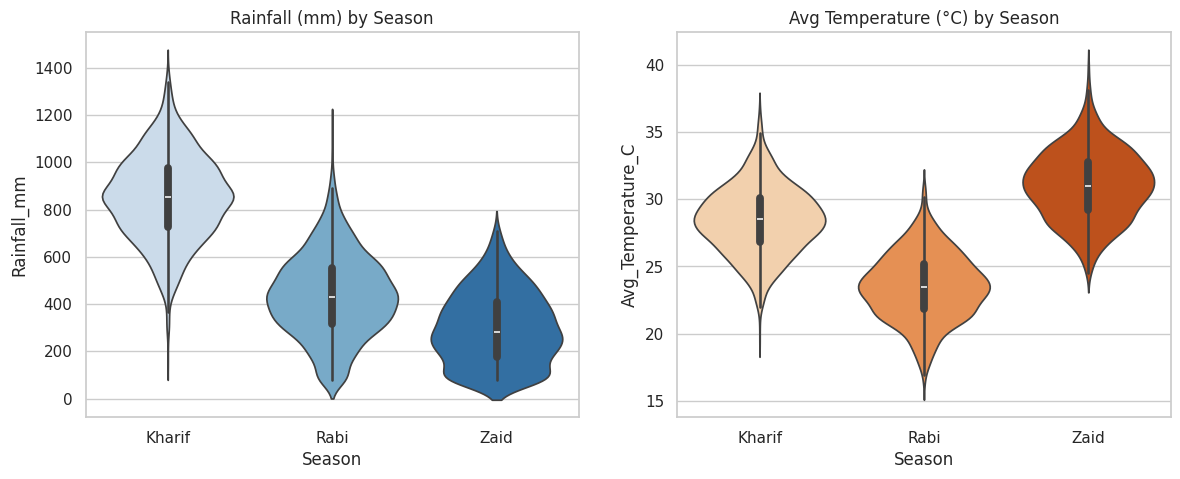

In [13]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.violinplot(data=df, x='Season', y='Rainfall_mm', ax=ax[0], palette='Blues')
ax[0].set_title("Rainfall (mm) by Season")

sns.violinplot(data=df, x='Season', y='Avg_Temperature_C', ax=ax[1], palette='Oranges')
ax[1].set_title("Avg Temperature (°C) by Season")

plt.savefig("03_rainfall_temperature.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4212/3432883850.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Water_Used_m3', ax=ax[0], palette='PuBu')
/tmp/ipykernel_4212/3432883850.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=ax[1], palette='YlGn')


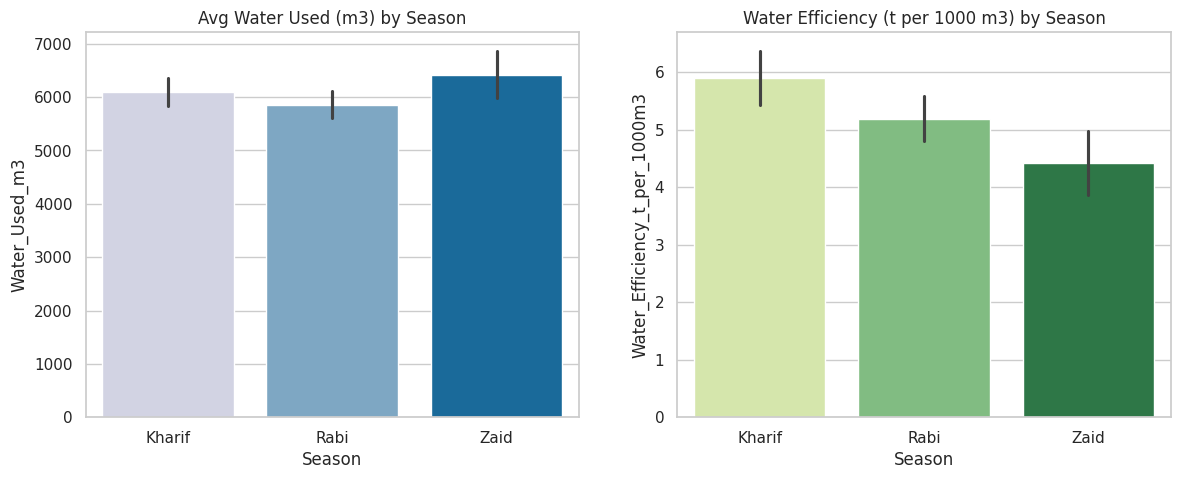

In [14]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.barplot(data=df, x='Season', y='Water_Used_m3', ax=ax[0], palette='PuBu')
ax[0].set_title("Avg Water Used (m3) by Season")

sns.barplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', ax=ax[1], palette='YlGn')
ax[1].set_title("Water Efficiency (t per 1000 m3) by Season")

plt.savefig("04_water_usage_efficiency.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_4212/2073088649.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Fertilizer_kg_ha', ax=ax[0], palette='Greens')
/tmp/ipykernel_4212/2073088649.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Pesticide_Litre_ha', ax=ax[1], palette='Reds')
/tmp/ipykernel_4212/2073088649.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Disease_Pest_Risk_pct', ax=ax[2], palette='RdPu')


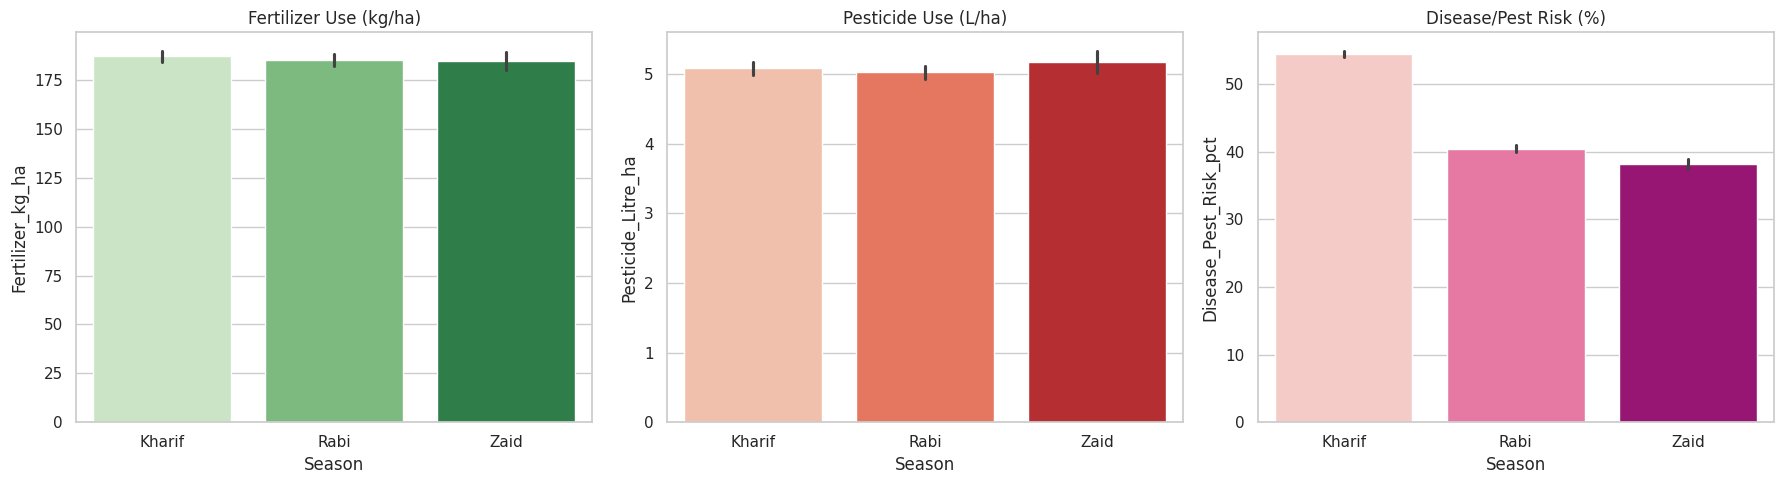

In [15]:
fig, ax = plt.subplots(1,3, figsize=(18,5))
sns.barplot(data=df, x='Season', y='Fertilizer_kg_ha', ax=ax[0], palette='Greens')
ax[0].set_title("Fertilizer Use (kg/ha)")

sns.barplot(data=df, x='Season', y='Pesticide_Litre_ha', ax=ax[1], palette='Reds')
ax[1].set_title("Pesticide Use (L/ha)")

sns.barplot(data=df, x='Season', y='Disease_Pest_Risk_pct', ax=ax[2], palette='RdPu')
ax[2].set_title("Disease/Pest Risk (%)")

plt.tight_layout()
plt.savefig("05_fertilizer_pesticide_disease.png", dpi=300, bbox_inches='tight')
plt.show()

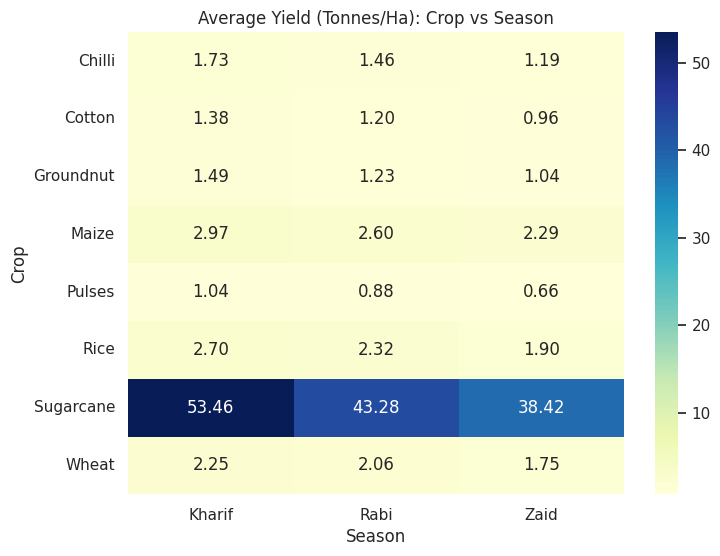

In [16]:
pivot = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='mean')
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Average Yield (Tonnes/Ha): Crop vs Season")
plt.savefig("06_crop_yield_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

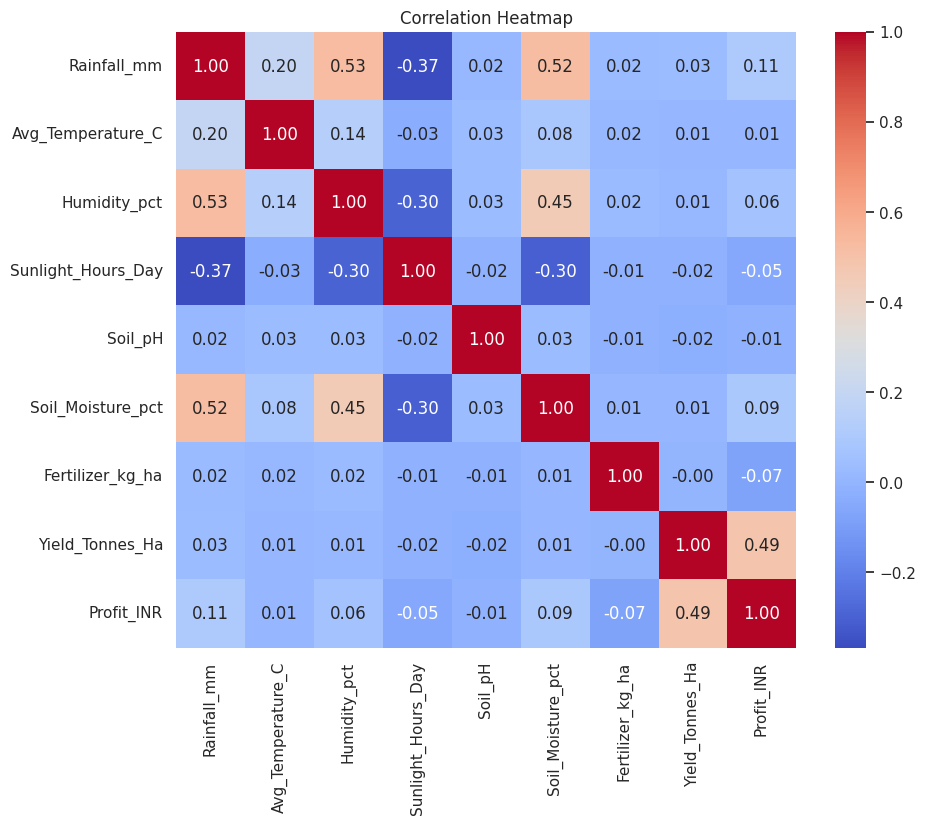

In [17]:
cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day',
        'Soil_pH','Soil_Moisture_pct','Fertilizer_kg_ha','Yield_Tonnes_Ha','Profit_INR']
plt.figure(figsize=(10,8))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("07_correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

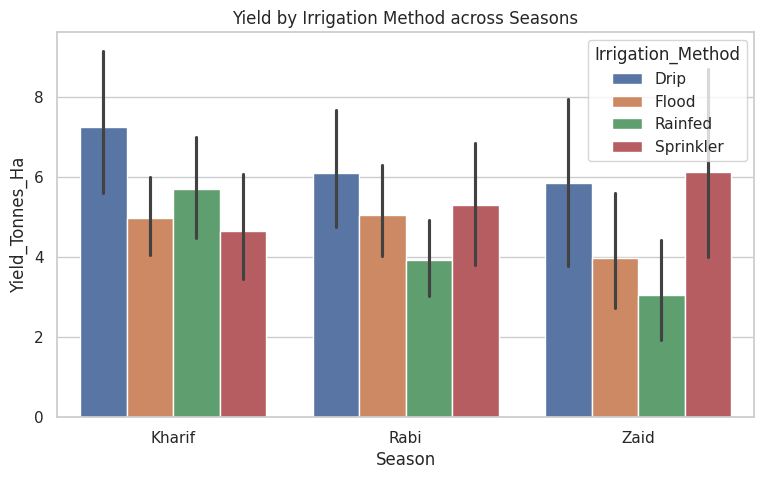

In [18]:
plt.figure(figsize=(9,5))
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', hue='Irrigation_Method')
plt.title("Yield by Irrigation Method across Seasons")
plt.savefig("08_irrigation_method_yield.png", dpi=300, bbox_inches='tight')
plt.show()

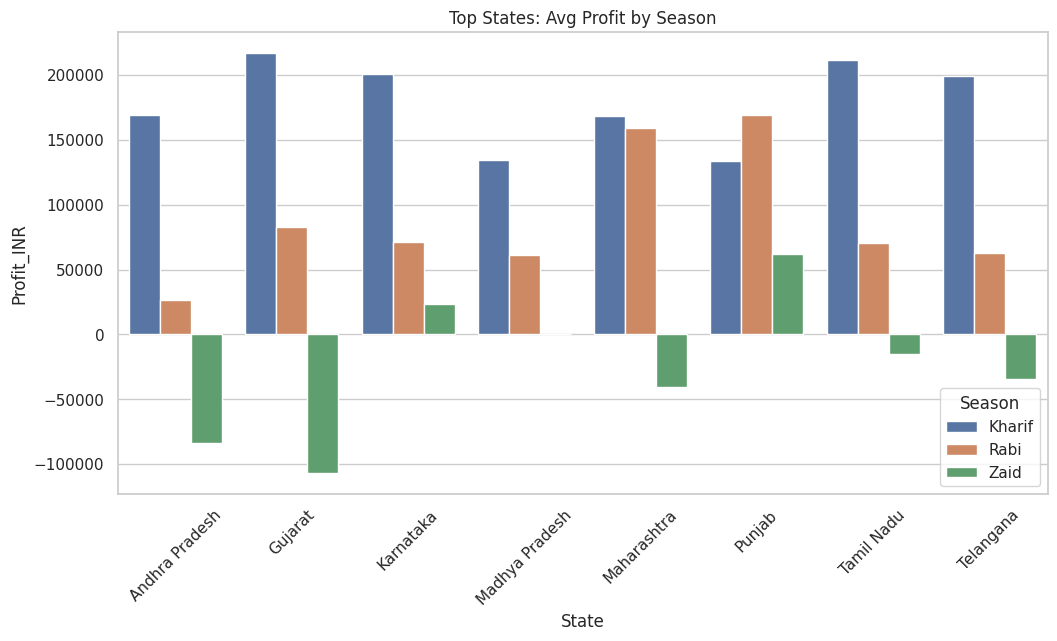

In [19]:
state_profit = df.groupby(['State','Season'])['Profit_INR'].mean().reset_index()
top_states = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False).head(8).index
plt.figure(figsize=(12,6))
sns.barplot(data=state_profit[state_profit['State'].isin(top_states)],
            x='State', y='Profit_INR', hue='Season')
plt.xticks(rotation=45)
plt.title("Top States: Avg Profit by Season")
plt.savefig("09_top_states_profit.png", dpi=300, bbox_inches='tight')
plt.show()

In [20]:
from scipy import stats
groups = [df[df['Season']==s]['Yield_Tonnes_Ha'] for s in df['Season'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.3f}, p-value: {p_val:.5f}")
if p_val < 0.05:
    print("=> Significant difference in Yield across seasons")
else:
    print("=> No significant difference in Yield across seasons")

ANOVA F-statistic: 1.554, p-value: 0.21156
=> No significant difference in Yield across seasons


### Key Insights

1. Kharif season demonstrates the strongest overall performance — highest average yield
   (5.63 t/ha), highest profit (₹1,78,915), and highest disease/pest risk (54.47%).

2. Zaid season shows the weakest economic performance — average profit is actually
   NEGATIVE (-₹24,805), meaning farms in Zaid season are running at a loss on average,
   despite using the highest water (6419.89 m³) among all seasons.

3. Yield decreases consistently from Kharif → Rabi → Zaid across every single crop
   (e.g., Sugarcane: 53.46 → 43.28 → 38.42 t/ha; Rice: 2.70 → 2.32 → 1.90 t/ha;
   Wheat: 2.25 → 2.06 → 1.75 t/ha), showing a clear seasonal decline pattern.

4. Sugarcane is by far the highest-yielding crop in all three seasons, far exceeding
   other crops (next highest is Maize at 2.97 t/ha in Kharif).

5. Despite Kharif showing the highest averages, the ANOVA test (F=1.554, p=0.212)
   indicates the yield difference across seasons is NOT statistically significant
   (p > 0.05) — meaning the seasonal variation seen may be due to natural spread in
   the data rather than a guaranteed seasonal effect.

6. Disease/Pest risk is notably higher in Kharif (54.47%) compared to Rabi (40.48%)
   and Zaid (38.22%) — likely linked to higher humidity/rainfall in that season.

7. Fertilizer and pesticide usage remain nearly constant across seasons (~185 kg/ha,
   ~5.1 L/ha), showing input usage does NOT scale down with falling yield in Zaid —
   an efficiency concern.

### Recommendations

1. Zaid season farming needs urgent cost-control measures — since average profit is
   negative, farmers should reconsider crop choice, reduce input costs, or improve
   water-use efficiency for this season specifically.

2. Since fertilizer/pesticide use stays constant while yield drops in Zaid, input
   application should be re-evaluated (possible over-application relative to output).

3. Prioritize disease/pest management programs during Kharif season, given its
   significantly higher risk percentage (54.47%).

4. Promote Sugarcane cultivation where feasible, as it consistently outperforms all
   other crops across every season by a wide margin.

5. Although Kharif shows the best raw numbers, the lack of statistical significance
   (ANOVA p=0.212) suggests seasonal planning should also consider crop type, region,
   and irrigation method together — not season alone.

6. Water allocation in Zaid should be reviewed, as it uses the most water (6419.89 m³)
   yet returns the lowest yield and a net loss — indicating poor water-use efficiency.

In [22]:
df.to_csv("cleaned_seasonal_agriculture_data.csv", index=False)
files.download("cleaned_seasonal_agriculture_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>